In [1]:
import sys
import os
import pandas as pd
from glob import glob
import os
import json

sys.path.append('../')

from analysis_utils import prepare_data
from data_utils import build_grid_image_with_target_highlight

RESTRICT_TO_VALID = True

REF_ANN_PATH = os.path.realpath(
    "../color-grid-segment-annotations/data/processed_annotations/consensus_majority_clean.json"
)  # preprocessed annotations for this project
COLORGRID_ANN_PATH = os.path.realpath(
    "../color-grid-segment-annotations/data/color_grid_data.json"
)  # original annotations (formatted)
LS_DATA_PATH = os.path.realpath(
    "../color-grid-segment-annotations/data/label_studio_input/label_studio_input.json"
)  # label studio inputs

In [2]:
INPUT_DIR = os.path.realpath('../output/generated_descriptions/')
input_files = glob(os.path.join(INPUT_DIR, '*.json'))
input_files_dict = {i: file for i, file in enumerate(input_files)}

In [3]:
ann_df, data_df, gameids, (far_ids, split_ids, close_ids) = prepare_data(REF_ANN_PATH, COLORGRID_ANN_PATH, LS_DATA_PATH)

read ann data...
read source data...
add further information from label studio data...


In [4]:
FILE = input_files_dict[0]
os.path.split(FILE)[-1]

'gemma-4-12B-it_descriptions.json'

In [5]:
with open(FILE, 'r') as f:
    json_content = json.load(f)
    model_id = json_content['model_id']
    args = json_content['args']
    responses = json_content['responses']
    
print(model_id)
print(*[f"{k}: {v}" for k, v in args.items()], sep='\n')

responses_df = pd.DataFrame(responses).set_index('target_id')

responses_df.description = responses_df.description.map(lambda x: x.strip() if isinstance(x, str) else x)
responses_df.reasoning = responses_df.reasoning.map(lambda x: x.strip() if isinstance(x, str) else x)

n_invalid = len(responses_df[responses_df.description.isna()])
print(f"{n_invalid} invalid entries ({round((n_invalid / len(responses_df)) * 100, 2)} %)")

responses_df = responses_df[~responses_df.description.isna()]
_data_df = data_df.set_index('round_id')

google/gemma-4-12B-it
out_dir: output/generated_descriptions
limit: None
ref_ann_path: consensus_majority_clean.json
colorgrid_ann_path: color_grid_data.json
ls_data_path: label_studio_input.json
instruction_file: model_instructions/model_description_guidelines_v2.txt
llm_server_ip: localhost
port: 8000
temperature: 0.0
top_p: 0.8
presence_penalty: 0.0
max_tokens: 32768
enable_thinking: False
max_concurrent: 40
patch_size: 100
patch_padding: 0
grid_padding: 50
target_padding: 50
0 invalid entries (0.0 %)


In [6]:
def display_example(row, data_df=_data_df, show_reasoning=False, scale=0.5):
    target_id = row.name
    row_data = data_df.loc[target_id]
    
    img = build_grid_image_with_target_highlight(row_data.objs, row_data.speaker_order, target_idx=row_data.speaker_order.index(0))

    print("=====================================")
    print(f"Item {target_id} ({row_data.condition} condition)")

    display(img.resize((int(img.size[0]*scale), int(img.size[1]*scale))))
    print('Description:', row.description)
    if show_reasoning:
        print('\n-------------------------\n')
        print('Reasoning:', row.reasoning)
    print("=====================================")    

Item 5370-ffc73313-d8a7-4a26-97e1-55bd32f4149c_49 (SPLIT condition)


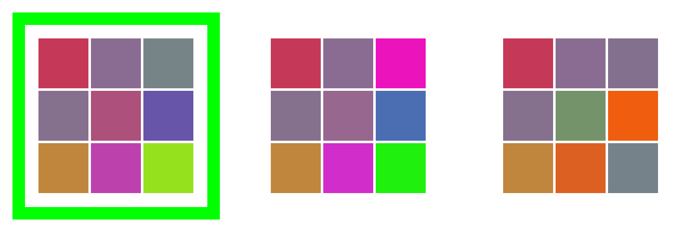

Description: Top row is red, purple, and magenta; middle row is grey, purple, and blue; bottom row is brown, magenta, and green.
Item 9597-b2286185-8375-4c3a-81a1-842be70a921e_44 (SPLIT condition)


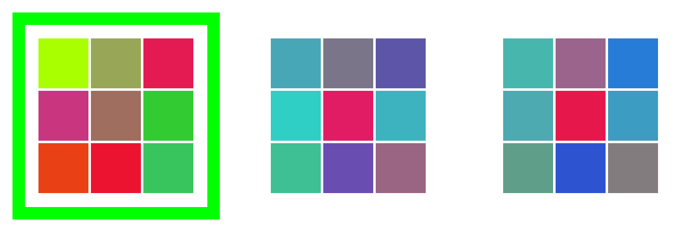

Description: A grid with a central red square, a blue square in the bottom middle, and a grey square in the bottom right.
Item 4875-b0bf8007-ee17-4937-b9a7-29326048fb83_7 (CLOSE condition)


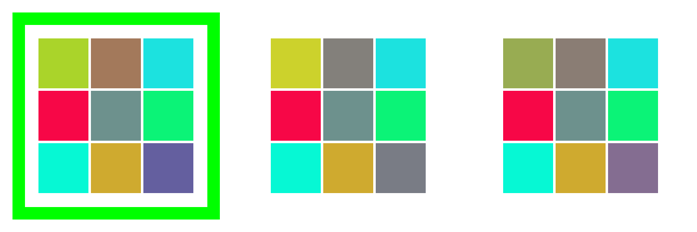

Description: Top row is yellow-green, gray, and cyan; middle row is red, slate gray, and bright green; bottom row is cyan, gold, and gray.
Item 6113-38555c00-9ed9-463a-ab14-04cdfb258539_43 (CLOSE condition)


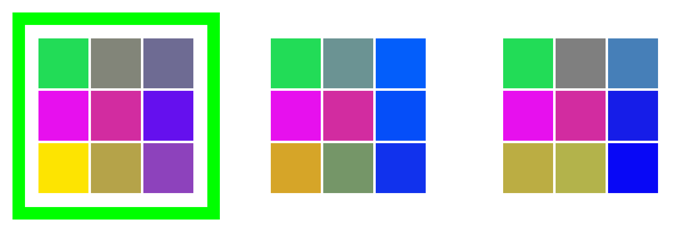

Description: Top row is green, grey, and dark blue; middle row is magenta, pink, and violet; bottom row is yellow, gold, and purple.
Item 2589-050e0f91-7dba-48c6-b219-c1d2a9b4eb39_21 (SPLIT condition)


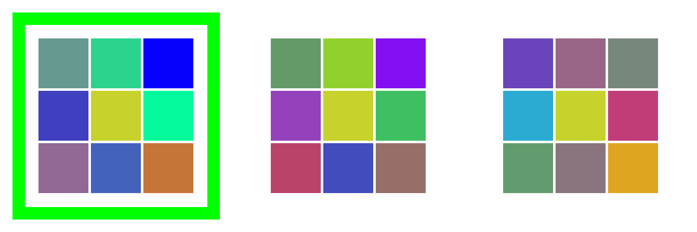

Description: Top row is gray-blue, turquoise, and blue; middle row is dark blue, yellow-green, and bright turquoise; bottom row is muted purple, medium blue, and orange-brown.
Item 1906-40c4b2ef-171b-4f0b-b70e-fb0955631406_36 (FAR condition)


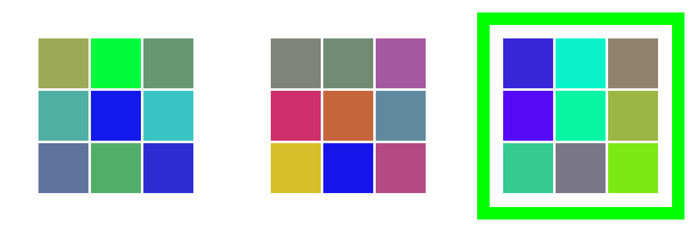

Description: Top row is blue, cyan, and brown; middle row is violet, turquoise, and olive; bottom row is teal, grey, and lime green.
Item 9955-1cbd5506-e782-422f-84e7-70366d4f805c_46 (SPLIT condition)


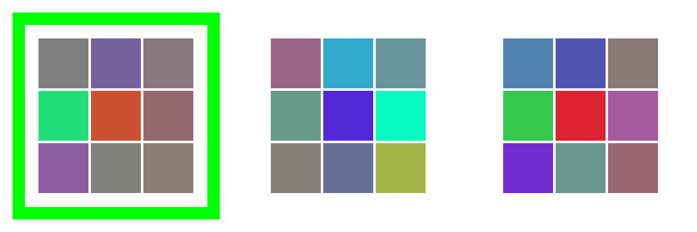

Description: Top row is blue, dark blue, and grey; middle row is green, red, and purple; bottom row is violet, teal, and brown.
Item 5704-eb65850a-01b8-43b7-ab26-937928c2f46c_26 (FAR condition)


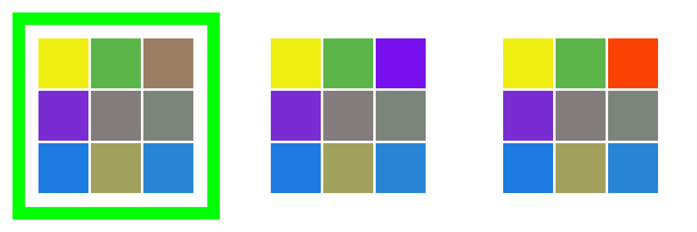

Description: Top row is yellow, green, and purple; middle row is purple, grey, and grey; bottom row is blue, tan, and blue.
Item 4875-b0bf8007-ee17-4937-b9a7-29326048fb83_46 (SPLIT condition)


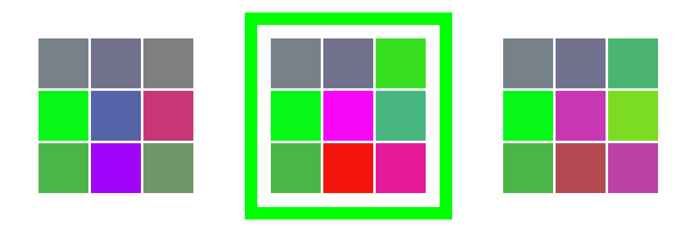

Description: Top row is dark gray, dark blue-gray, and bright green; middle row is bright green, magenta, and teal; bottom row is medium green, red, and pink.
Item 5948-6739fbf7-ad1a-4a61-bcbb-03cd77eb7b66_57 (CLOSE condition)


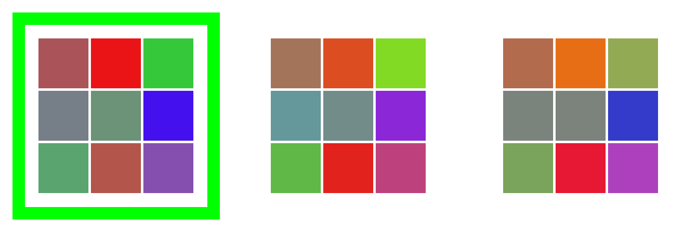

Description: Top row is brown, orange, and olive; middle row is grey, grey, and blue; bottom row is olive, red, and purple.


In [7]:
sample = responses_df.sample(10, random_state=123)

for _, row in sample.iterrows():
    display_example(row)